# Noise-correlation PSTHs by brain region and LDA-1 bin (clean, matched to ff_psth_ldabin)
Time-resolved within-region mean spike-count correlation per session x region (condition-adjusted: stimulus side x contrast means removed before correlating), then averaged across sessions within each LDA-1 bin. Same controls as ff_psth_ldabin: causal window, per-session trial subsampling (balancing) with repeats, optional neuron cap, region selection, autoscaled y.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from scipy.ndimage import uniform_filter1d
from iblatlas.regions import BrainRegions
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [ ]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/'

REGION_LEVEL = 'beryl'    # 'cosmos' | 'beryl'
DROP = ['root', 'void']
DROP = ['void']
WIN_BINS = 6               # sliding-window width (bins) for the spike-count correlation
SMOOTH_MODE = 'causal'     # 'causal' (only bins <= t) or 'centered'
MIN_NEURONS = 15
N_BINS = 5                 # LDA-1 bins (lda['binned1'])
REMOVE_CONDITION = True    # subtract stimulus (side x contrast) means before correlating -> noise r_SC
BALANCE_SESSIONS = False    # subsample each session to a common trial count (uniform bias across bins)
SESSION_N_TARGET = 100     # complete trials per session when balancing (sessions with fewer are skipped)
N_SUBSAMPLE_REPEATS = 10   # average r_SC over this many random subsamples
N_NEURONS_CAP = None       # if int, subsample each region to this many neurons
SEED = 0
CORRECT_ONLY = False     # if True, use only correct trials
GOCUE_TOL = 0.01           # seconds - tolerance for validating trial_id alignment against ONE
N_PERM = 2000              # permutation iterations for the session-stratified lda_1 GLM test below

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
lda['bin'] = lda['binned1'].cat.codes
bin_map = dict(zip(lda['session'], lda['bin']))

# Trial outcome fetched live from ONE and precomputed by precompute_session_trial_meta.ipynb,
# replacing the deprecated-pipeline all_trials_04-05-2026 (which silently dropped every no-go
# trial - see noise_corr_psth_conditions.ipynb history). Note: outcome is 'feedback'
# ('correct'/'incorrect' strings), not the old file's numeric 'correct' column.
session_trial_meta = pd.read_parquet(prefix + '4_mice/session_trial_meta_03-07-2026')
correct_by_session = (session_trial_meta[session_trial_meta['feedback'] == 'correct']
                       .groupby('session')['trial_id'].apply(set).to_dict())
gocue_by_session = {s: g.set_index('trial_id')['goCueTrigger_times']
                    for s, g in session_trial_meta.groupby('session')}
br = BrainRegions()
print(f"LDA sessions: {lda['session'].nunique()}, bins: {sorted(lda['bin'].unique())}")

## Compute one noise-correlation PSTH per session x region

In [12]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)

def smooth_time(A, W, mode):
    if mode == 'centered':
        return uniform_filter1d(A, W, axis=2, mode='nearest')
    c = np.cumsum(A, axis=2); out = np.empty_like(A)
    out[..., :W] = c[..., :W] / np.arange(1, W + 1)
    out[..., W:] = (c[..., W:] - c[..., :-W]) / W
    return out

def rsc_curve(A, cond=None):
    """A: neurons x trials x T (complete trials). Mean off-diagonal correlation per time bin,
    optionally after removing stimulus-condition means (noise correlation)."""
    R = A.astype(float)
    if REMOVE_CONDITION and cond is not None:
        R = R.copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            R[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
    mean = np.nanmean(R, axis=1, keepdims=True); std = np.nanstd(R, axis=1, ddof=1, keepdims=True)
    Z = (R - mean) / std
    Z[~np.isfinite(Z)] = np.nan
    nL = R.shape[1]
    s = np.nansum(Z, axis=0); sumsq = np.nansum(s ** 2, axis=0)
    nvalid = ((np.isfinite(std[:, 0, :])) & (std[:, 0, :] > 0)).sum(0).astype(float)
    with np.errstate(invalid='ignore', divide='ignore'):
        off = (sumsq / (nL - 1) - nvalid) / (nvalid * (nvalid - 1))
    off[nvalid < 2] = np.nan
    return off

rng = np.random.default_rng(SEED)
records = []
n_session_mismatch = 0
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        if session not in bin_map: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}

        # Validate the trial_id join against ONE before trusting correct_by_session for this
        # session: compare this file's own per-trial event_time against ONE's
        # goCueTrigger_times at the same trial_id (see noise_corr_psth_conditions.ipynb).
        gocue = gocue_by_session.get(session)
        if gocue is None: continue
        own_event_time = d.drop_duplicates('trial_id').set_index('trial_id')['event_time'].reindex(trials)
        one_event_time = gocue.reindex(trials)
        mismatch = (own_event_time - one_event_time).abs() > GOCUE_TOL
        if mismatch.any():
            n_session_mismatch += 1
            print(f"  Skipping session {session}: {int(mismatch.sum())}/{len(trials)} trial_id "
                  f"mismatches vs ONE (goCueTrigger_times)")
            continue

        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values

        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        cond_all = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials).values
        corr_set = correct_by_session.get(session, set())
        correct_mask = np.array([t in corr_set for t in trials]) if CORRECT_ONLY else np.ones(len(trials), dtype=bool)

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue
            if N_NEURONS_CAP and len(ni) > N_NEURONS_CAP:
                ni = rng.choice(ni, N_NEURONS_CAP, replace=False)
            Asub = A[ni]
            complete = ~np.isnan(Asub).any(axis=(0, 2))          # r_SC is pairwise -> need shared trials
            comp_idx = np.where(complete & correct_mask)[0]   # correct-only if toggled
            Aw = smooth_time(Asub[:, comp_idx, :], WIN_BINS, SMOOTH_MODE)
            conds = cond_all[comp_idx]
            if BALANCE_SESSIONS:
                if len(comp_idx) < SESSION_N_TARGET: continue
                reps = []
                for _ in range(N_SUBSAMPLE_REPEATS):
                    s = rng.choice(len(comp_idx), SESSION_N_TARGET, replace=False)
                    reps.append(rsc_curve(Aw[:, s, :], conds[s]))
                curve = np.nanmean(reps, axis=0); n_used = SESSION_N_TARGET
            else:
                if len(comp_idx) < MIN_NEURONS: continue
                curve = rsc_curve(Aw, conds); n_used = len(comp_idx)
            records.append(dict(session=session, region=region, bin=bin_map[session],
                                n_neurons=len(ni), n_trials=n_used, curve=curve))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

curves = pd.DataFrame(records)
print(f"Computed {len(curves)} session-region curves | {curves['session'].nunique()} sessions | "
      f"regions: {sorted(curves['region'].unique())}")
if n_session_mismatch:
    print(f"{n_session_mismatch} pid files skipped due to trial_id/goCueTrigger_times mismatch vs ONE")

  100/374 files...
  200/374 files...
  300/374 files...
Computed 1041 session-region curves | 230 sessions | regions: ['ACAd', 'ACAv', 'ACB', 'AId', 'AIp', 'AIv', 'AM', 'ANcr1', 'ANcr2', 'AON', 'APN', 'AV', 'BLA', 'BST', 'CA1', 'CA3', 'CEA', 'CENT2', 'CENT3', 'CL', 'CLA', 'COAa', 'COPY', 'CP', 'CS', 'CUL4 5', 'CUN', 'DCO', 'DEC', 'DG', 'DN', 'DP', 'DTN', 'ECT', 'ENTl', 'ENTm', 'EPd', 'EPv', 'Eth', 'FL', 'FN', 'FOTU', 'FRP', 'FS', 'GPe', 'GPi', 'GRN', 'HATA', 'IC', 'ICB', 'ILA', 'IP', 'IRN', 'LA', 'LAV', 'LD', 'LDT', 'LGd', 'LGv', 'LHA', 'LP', 'LPO', 'LSc', 'LSr', 'LSv', 'MARN', 'MD', 'MDRN', 'MEA', 'MG', 'MOB', 'MOp', 'MOs', 'MPO', 'MRN', 'MS', 'MV', 'NB', 'NDB', 'NI', 'NLL', 'NOD', 'NPC', 'NTS', 'ORBl', 'ORBm', 'ORBvl', 'OT', 'PAA', 'PAG', 'PAR', 'PARN', 'PB', 'PCG', 'PCN', 'PF', 'PFL', 'PGRN', 'PIR', 'PL', 'PO', 'POL', 'POST', 'PPN', 'PRE', 'PRM', 'PRNc', 'PRNr', 'PRP', 'PS', 'PSV', 'PVT', 'PYR', 'PoT', 'ProS', 'RN', 'RSPagl', 'RSPd', 'RSPv', 'RT', 'SAG', 'SCm', 'SCs', 'SF', 'SGN', 

## Plot: r_SC PSTH per region, colored by LDA-1 bin

In [13]:
def bins_by_session(df_sub):
    per_sess = (df_sub.groupby(['session', 'bin'])['curve']
                .apply(lambda cs: np.nanmean(np.vstack(cs.values), axis=0)).reset_index())
    return {b: np.vstack(g['curve'].values) for b, g in per_sess.groupby('bin')}

def plot_one(ax, df_sub, title, xlim=(-0.5, 1)):
    colors = plt.cm.coolwarm(np.linspace(0, 1, N_BINS))
    agg = bins_by_session(df_sub)
    xmask = (tsec >= xlim[0]) & (tsec <= xlim[1]); yv = []
    for b in range(N_BINS):
        if b not in agg: continue
        M = agg[b]; mean = np.nanmean(M, axis=0)
        ax.plot(tsec, mean, color=colors[b], lw=2, label=f'bin {b} (N={M.shape[0]})')
        if M.shape[0] > 1:
            sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
            ax.fill_between(tsec, mean - sem, mean + sem, color=colors[b], alpha=0.15)
            yv += [(mean - sem)[xmask], (mean + sem)[xmask]]
        else:
            yv += [mean[xmask]]
    ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('mean r_SC'); ax.set_title(title, fontsize=11)
    ax.set_xlim(list(xlim))
    if yv:
        allv = np.concatenate(yv); lo, hi = np.nanmin(allv), np.nanmax(allv)
        pad = 0.05 * (hi - lo) if hi > lo else 0.05 * abs(hi) + 1e-6
        ax.set_ylim(lo - pad, hi + pad)
    ax.legend(fontsize=8); sns.despine(ax=ax, offset=4)

def plot_regions(regions=None):
    d = curves if regions is None else curves[curves['region'].isin(regions)]
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_one(ax, d, f'r_SC PSTH by LDA-1 bin ({"all regions" if regions is None else regions})')
    plt.tight_layout(); plt.show()

In [14]:
# region_order = curves.groupby('region')['session'].nunique().sort_values(ascending=False).index.tolist()
# ncols = 4; nrows = int(np.ceil(len(region_order) / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
# for k, region in enumerate(region_order):
#     plot_one(axes[k // ncols][k % ncols], curves[curves['region'] == region],
#              f'{region} ({curves[curves.region==region]["session"].nunique()} sessions)')
# for k in range(len(region_order), nrows * ncols):
#     axes[k // ncols][k % ncols].axis('off')
# fig.suptitle('Noise-correlation PSTH by region and LDA-1 bin', y=1.01, fontsize=14, fontweight='bold')
# plt.tight_layout(); plt.show()

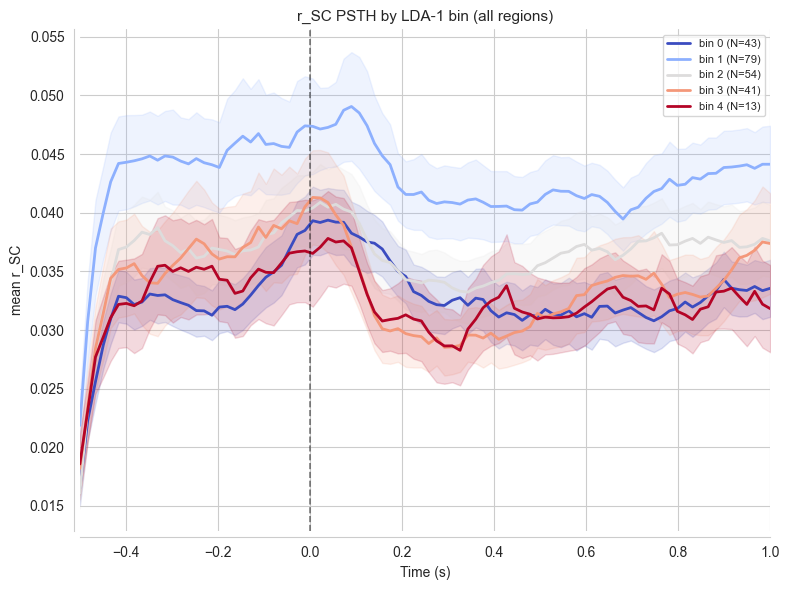

In [15]:
REGIONS = ['VISp', 'VISa', 'VISam', 'VISal', 'VISl', 'VISli', 'VISpl', 'VISpm', 'VISpor', 'VISrl']
REGIONS = None
plot_regions(regions=REGIONS)              # averaged across all regions
# plot_regions(regions=['Isocortex'])     # a specific region (edit as needed)

## Baseline-subtracted r_SC PSTH

Subtracts each curve's *own* pre-stimulus baseline (mean r_SC in `BASELINE_WINDOW`, default
`[-0.1, 0]`s) from itself, rather than a shared per-region or per-session average. Baseline
correlation magnitude varies a lot across sessions/regions for reasons unrelated to the
science (recording depth, electrode yield, region-specific baseline connectivity) - removing
each curve's own baseline cancels that out and isolates the dynamic modulation around the
event, which is what's actually of interest here. A shared region-wide baseline would leave
session-to-session offset differences intact instead of removing them.

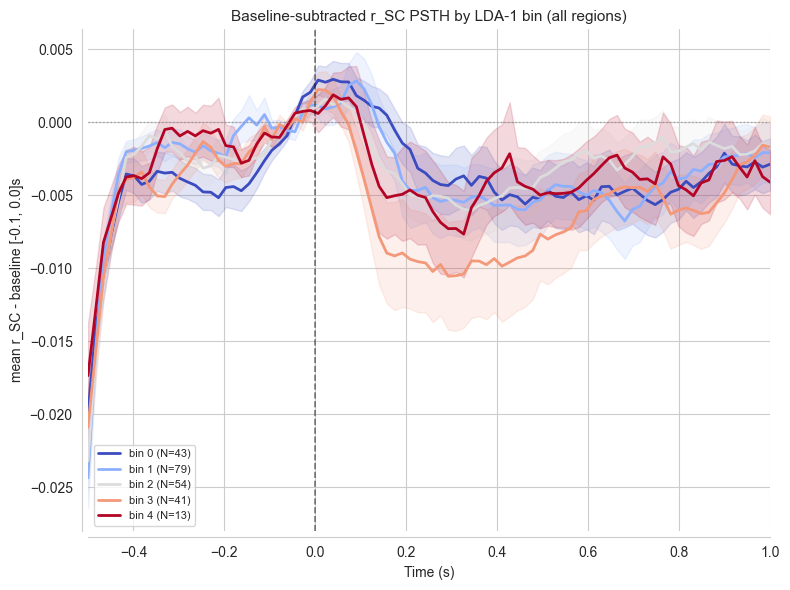

In [16]:
BASELINE_WINDOW = (-0.1, 0.0)   # seconds, relative to event onset

bmask = (tsec >= BASELINE_WINDOW[0]) & (tsec <= BASELINE_WINDOW[1])
if not bmask.any():
    raise ValueError(f"No time bins fall inside BASELINE_WINDOW {BASELINE_WINDOW} "
                      f"(tsec range [{tsec.min():.2f}, {tsec.max():.2f}])")

curves_baseline = curves.copy()
curves_baseline['curve'] = curves_baseline['curve'].apply(lambda c: c - np.nanmean(c[bmask]))

def plot_regions_baseline(regions=None):
    d = curves_baseline if regions is None else curves_baseline[curves_baseline['region'].isin(regions)]
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_one(ax, d, f'Baseline-subtracted r_SC PSTH by LDA-1 bin ({"all regions" if regions is None else regions})')
    ax.axhline(0, color='grey', ls=':', alpha=0.6, lw=1)
    ax.set_ylabel(f'mean r_SC - baseline [{BASELINE_WINDOW[0]}, {BASELINE_WINDOW[1]}]s')
    plt.tight_layout(); plt.show()

plot_regions_baseline(regions=None)              # averaged across all regions
# plot_regions_baseline(regions=['Isocortex'])   # a specific region (edit as needed)

## Session-averaged r_SC in a time window vs. continuous LDA-1

Instead of discretizing into LDA bins, average each session's r_SC curve over a chosen time
window (e.g. a pre-stimulus baseline) and correlate that single scalar per session against the
continuous `lda_1` value directly.

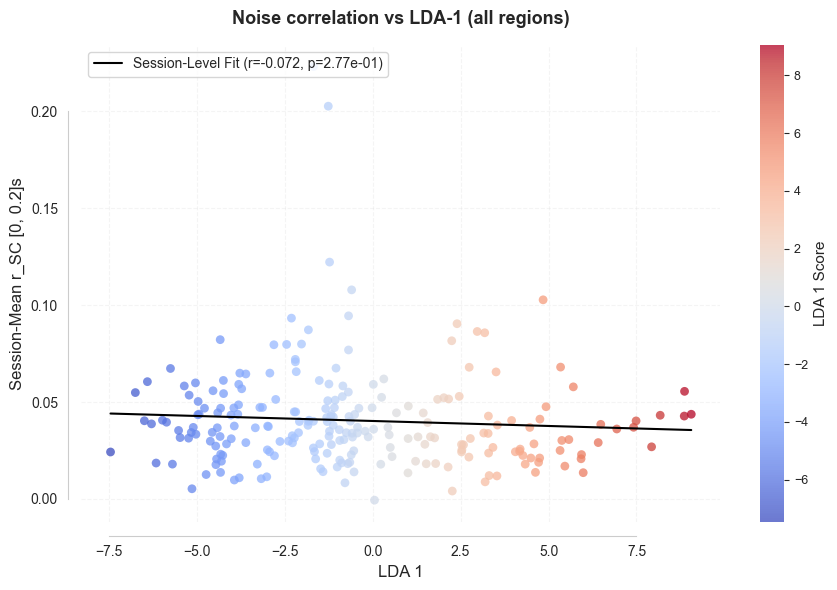

Total number of independent sessions plotted: 230


In [17]:
from scipy.stats import linregress

CORR_WINDOW = (0, 0.2)   # seconds, relative to event onset

def session_window_avg(df, window, regions=None):
    """Mean r_SC in [window[0], window[1]] per session. Rows (region x n_neurons entries)
    within a session are averaged with equal weight, same convention as plot_one/bins_by_session."""
    d = df if regions is None else df[df['region'].isin(regions)]
    if len(d) == 0:
        return pd.Series(dtype=float)
    wmask = (tsec >= window[0]) & (tsec <= window[1])
    if not wmask.any():
        raise ValueError(f"No time bins fall inside window {window} (tsec range "
                          f"[{tsec.min():.2f}, {tsec.max():.2f}])")
    per_row = d['curve'].apply(lambda c: np.nanmean(c[wmask]))
    return pd.DataFrame({'session': d['session'].values, 'window_rsc': per_row.values}) \
        .groupby('session')['window_rsc'].mean()

def plot_lda_correlation(df, window=CORR_WINDOW, regions=None, title=None):
    """Session-level gradient scatter plot, matching the style used elsewhere in this folder
    for LDA-1 correlations (e.g. fano_factor/ff_quench.ipynb): dots colored by lda_1 itself
    via coolwarm, black linregress fit line, colorbar, dashed grid, trimmed despine."""
    window_avg = session_window_avg(df, window, regions)
    session_df = (pd.DataFrame({'window_rsc': window_avg})
                  .join(lda.set_index('session')['lda_1'], how='inner')
                  .dropna().reset_index())
    if len(session_df) < 3:
        print(f"Only {len(session_df)} sessions with both a window average and an lda_1 value - too few to correlate")
        return session_df

    x = session_df['lda_1'].values
    y = session_df['window_rsc'].values
    slope, intercept, r, p, se = linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept

    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.75, s=40, edgecolors='none')
    ax.plot(x_fit, y_fit, color='black', linewidth=1.5,
            label=f'Session-Level Fit (r={r:.3f}, p={p:.2e})')

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('LDA 1 Score', fontsize=11)
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False)

    region_label = "all regions" if regions is None else regions
    ax.set_xlabel('LDA 1', fontsize=12)
    ax.set_ylabel(f'Session-Mean r_SC [{window[0]}, {window[1]}]s', fontsize=12)
    ax.set_title(title or f'Noise correlation vs LDA-1 ({region_label})', fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.legend(fontsize=10, loc='upper left', frameon=True)
    sns.despine(ax=ax, offset=10, trim=True)
    fig.tight_layout(); plt.show()

    print(f"Total number of independent sessions plotted: {len(session_df)}")
    return session_df, r, p

_ = plot_lda_correlation(curves, window=CORR_WINDOW, regions=None)

## Mixed-model test of the lda_1 effect on noise correlation

Tests whether `lda_1` predicts the session-region window-averaged r_SC, controlling for
`n_neurons` and `n_trials` (both vary meaningfully when `BALANCE_SESSIONS=False`, which is
the current setting - if you switch `BALANCE_SESSIONS` back to `True`, `n_trials` becomes
constant at `SESSION_N_TARGET` for every row and should be dropped from the formulas below,
since trial-count confounding is then already eliminated upstream by the subsampling itself).

`region` is genuinely *crossed* with session/mouse (the same region label, e.g. "VISa",
recurs across many different sessions/mice - it isn't nested within one), while session is
nested within mouse. Since it wasn't obvious which structure is "correct" here, all 4
combinations are fit and compared side by side:
- region as a fixed effect (`C(region)`) vs. a random intercept (variance component)
- grouping by session only (matches the existing `ff_quench.ipynb` convention in this repo)
  vs. session properly nested within mouse (accounts for the 56 mice x 3-13 sessions each
  in this dataset, avoiding pseudo-replication since `lda_1` is a per-session value)

In [18]:
import statsmodels.formula.api as smf

lmm_df = curves[['session', 'region', 'n_neurons', 'n_trials', 'curve']].copy()
wmask_lmm = (tsec >= CORR_WINDOW[0]) & (tsec <= CORR_WINDOW[1])
lmm_df['window_rsc'] = lmm_df['curve'].apply(lambda c: np.nanmean(c[wmask_lmm]))
lmm_df = lmm_df.merge(lda[['session', 'lda_1', 'mouse_name']], on='session', how='left')
lmm_df = lmm_df.dropna(subset=['window_rsc', 'lda_1', 'n_neurons', 'n_trials', 'region', 'mouse_name'])
# z-score n_neurons/n_trials for numerical stability/comparable coefficient scale.
# NOTE: n_trials is only usable as a covariate when BALANCE_SESSIONS=False - with
# BALANCE_SESSIONS=True every row is forced to exactly SESSION_N_TARGET trials (zero
# variance), in which case drop it from the formulas below instead.
lmm_df['n_neurons_z'] = (lmm_df['n_neurons'] - lmm_df['n_neurons'].mean()) / lmm_df['n_neurons'].std()
lmm_df['n_trials_z'] = (lmm_df['n_trials'] - lmm_df['n_trials'].mean()) / lmm_df['n_trials'].std()

print(f"N rows: {len(lmm_df)}, N sessions: {lmm_df['session'].nunique()}, "
      f"N mice: {lmm_df['mouse_name'].nunique()}, N regions: {lmm_df['region'].nunique()}")
print(f"n_trials range: {lmm_df['n_trials'].min()}-{lmm_df['n_trials'].max()} "
      f"({'constant - drop n_trials_z from the formulas below' if lmm_df['n_trials'].nunique() == 1 else 'varies, kept as covariate'})")

lmm_results = {}

# A) region fixed, grouping = session only (matches existing ff_quench.ipynb convention)
lmm_results['A: region fixed, session-only'] = smf.mixedlm(
    "window_rsc ~ lda_1 + n_neurons_z + n_trials_z + C(region)", lmm_df, groups=lmm_df['session']).fit(reml=True)

# B) region fixed, session nested within mouse
lmm_results['B: region fixed, mouse>session nested'] = smf.mixedlm(
    "window_rsc ~ lda_1 + n_neurons_z + n_trials_z + C(region)", lmm_df, groups=lmm_df['mouse_name'],
    vc_formula={'session': '0 + C(session)'}).fit(reml=True)

# C) region random (variance component), grouping = session only
lmm_results['C: region random, session-only'] = smf.mixedlm(
    "window_rsc ~ lda_1 + n_neurons_z + n_trials_z", lmm_df, groups=lmm_df['session'],
    vc_formula={'region': '0 + C(region)'}).fit(reml=True)

# D) region random (crossed vc), session nested within mouse
lmm_results['D: region random, mouse>session nested'] = smf.mixedlm(
    "window_rsc ~ lda_1 + n_neurons_z + n_trials_z", lmm_df, groups=lmm_df['mouse_name'],
    vc_formula={'session': '0 + C(session)', 'region': '0 + C(region)'}).fit(reml=True)

print(f"\n{'Model':<40} {'coef':>9} {'SE':>9} {'z':>7} {'p':>10} {'logLik':>10}")
for name, r in lmm_results.items():
    print(f"{name:<40} {r.params['lda_1']:>9.4f} {r.bse['lda_1']:>9.4f} "
          f"{r.tvalues['lda_1']:>7.2f} {r.pvalues['lda_1']:>10.3g} {r.llf:>10.1f}")

N rows: 1041, N sessions: 230, N mice: 56, N regions: 167
n_trials range: 38-353 (varies, kept as covariate)

Model                                         coef        SE       z          p     logLik
A: region fixed, session-only              -0.0008    0.0004   -2.12     0.0341     1632.9
B: region fixed, mouse>session nested      -0.0008    0.0004   -2.12     0.0341     1632.9
C: region random, session-only             -0.0006    0.0003   -1.65     0.0985     1933.8
D: region random, mouse>session nested     -0.0006    0.0005   -1.35      0.178     1948.9


## Session-region r_SC vs LDA-1: GLM + session-permutation test + Bayes factor (same framework as `ff_psth_ldabin.ipynb`)
Applies the same three-part test used for the single-neuron Fano-factor metrics to noise
correlations, adapted to the level r_SC is naturally computed at: **session x region**, not
single neuron (r_SC is inherently pairwise, already averaged across neuron pairs within a
region for a session in `curves['curve']` -- no need to touch the raw spike data again).

Three r_SC summaries, extracted from each session-region's PSTH curve computed above:
- `r_sc_pre`: mean r_SC in the pre-stimulus baseline window (`BASELINE_WINDOW`)
- `r_sc_post`: mean r_SC in the post-stimulus window (`CORR_WINDOW`)
- `r_sc_quench = r_sc_pre - r_sc_post`: the pre -> post drop in correlated variability (mirrors
  Fano-factor quenching; positive = correlations decrease after stimulus onset)

Model: `metric ~ lda_1 + C(region) + n_trials + n_neurons`, matching the covariates already used
in the mixed-model section above. None of these are log-transformed -- r_SC can be negative, so
they stay on their natural scale (the paper's own rule for signed metrics).

As in `ff_psth_ldabin.ipynb`: the GLM slope of `lda_1` is the test statistic, its permutation null
shuffles `lda_1` across **sessions** (all regions within a session move together), and the Bayes
factor is the partial-correlation JZS Bayes factor (Wetzels & Wagenmakers, 2012) via
`pingouin.bayesfactor_pearson`, computed on residuals after regressing out the other covariates
(Frisch-Waugh-Lovell) -- in place of the R `BayesFactor` package.

In [ ]:
from scipy.stats import pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

pre_mask_rsc = (tsec >= BASELINE_WINDOW[0]) & (tsec <= BASELINE_WINDOW[1])
post_mask_rsc = (tsec >= CORR_WINDOW[0]) & (tsec <= CORR_WINDOW[1])

rsc_df = curves[['session', 'region', 'n_neurons', 'n_trials', 'curve']].copy()
rsc_df['r_sc_pre'] = rsc_df['curve'].apply(lambda c: np.nanmean(c[pre_mask_rsc]))
rsc_df['r_sc_post'] = rsc_df['curve'].apply(lambda c: np.nanmean(c[post_mask_rsc]))
rsc_df['r_sc_quench'] = rsc_df['r_sc_pre'] - rsc_df['r_sc_post']
rsc_df = rsc_df.merge(lda[['session', 'lda_1']], on='session', how='left')
rsc_df = rsc_df.dropna(subset=['r_sc_pre', 'r_sc_post', 'r_sc_quench', 'lda_1']).reset_index(drop=True)
print(f"r_SC table: {len(rsc_df)} session-region rows | {rsc_df['session'].nunique()} sessions | "
      f"{rsc_df['region'].nunique()} regions")

In [ ]:
def _design_matrix(df, region_col='region', extra_covars=('n_trials', 'n_neurons')):
    """Intercept + region dummies (drop first) + extra numeric covariates, as a plain array."""
    dummies = pd.get_dummies(df[region_col], drop_first=True)
    Z = pd.concat([pd.Series(1.0, index=df.index, name='Intercept'), dummies,
                   df[list(extra_covars)].astype(float)], axis=1)
    return Z.values.astype(float)

def age_effect_test(df, y_col, predictor='lda_1', region_col='region', extra_covars=('n_trials', 'n_neurons'),
                     n_perm=N_PERM, seed=SEED, label=None):
    """Same test as ff_psth_ldabin.ipynb's age_effect_test, with `predictor` = lda_1: GLM slope
    as test statistic, session-stratified permutation p-value, and a partial-correlation Bayes
    factor in place of the R BayesFactor package."""
    d = df.dropna(subset=[y_col, predictor, region_col] + list(extra_covars)).reset_index(drop=True)
    y = d[y_col].values.astype(float)
    x = d[predictor].values.astype(float)
    Z = _design_matrix(d, region_col, extra_covars)
    Zpinv = np.linalg.pinv(Z)

    # Frisch-Waugh-Lovell: residualize y and the predictor on all other covariates once; the
    # slope of y_resid on x_resid equals the predictor's coefficient in the full multiple GLM.
    y_resid = y - Z @ (Zpinv @ y)
    x_resid_obs = x - Z @ (Zpinv @ x)
    slope_obs = np.sum(x_resid_obs * y_resid) / np.sum(x_resid_obs ** 2)

    r_partial, _ = pearsonr(x_resid_obs, y_resid)
    n_eff = max(len(d) - (Z.shape[1] - 1), 3)   # drop df used by region dummies + extra covariates
    bf10 = pg.bayesfactor_pearson(r_partial, n_eff)

    # Permutation: shuffle the predictor across SESSIONS (not session-region rows), preserving
    # within-session grouping (all regions of a session move together), as in the paper's
    # session-based label shuffling for neural metrics.
    sess_to_x = d.groupby('session')[predictor].first()
    sess_index = d['session'].values
    rng = np.random.default_rng(seed)
    perm_slopes = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = pd.Series(rng.permutation(sess_to_x.values), index=sess_to_x.index)
        x_perm = shuffled.reindex(sess_index).values.astype(float)
        x_perm_resid = x_perm - Z @ (Zpinv @ x_perm)
        perm_slopes[i] = np.sum(x_perm_resid * y_resid) / np.sum(x_perm_resid ** 2)
    p_perm = np.mean(np.abs(perm_slopes) >= np.abs(slope_obs))

    # Sanity-check fit via statsmodels GLM (Gaussian, identity link) for a human-readable summary.
    gdf = d.copy(); gdf['_y'] = y
    formula = f"_y ~ {predictor} + C({region_col}) + " + ' + '.join(extra_covars)
    glm_fit = smf.glm(formula, data=gdf, family=sm.families.Gaussian()).fit()

    return dict(label=label or y_col, n=len(d), n_sessions=d['session'].nunique(),
                slope=slope_obs, r_partial=r_partial, bf10=bf10, p_perm=p_perm,
                glm_slope=glm_fit.params[predictor], glm_p=glm_fit.pvalues[predictor])

def bf_label(bf):
    if bf > 10: return 'strong H1'
    if bf > 3: return 'moderate H1'
    if bf < 1 / 10: return 'strong H0'
    if bf < 1 / 3: return 'moderate H0'
    return 'inconclusive'

rsc_results = {
    'r_SC pre (baseline)': age_effect_test(rsc_df, 'r_sc_pre',
                                            label='r_sc_pre ~ lda_1 + C(region) + n_trials + n_neurons'),
    'r_SC post (stimulus)': age_effect_test(rsc_df, 'r_sc_post',
                                             label='r_sc_post ~ lda_1 + C(region) + n_trials + n_neurons'),
    'r_SC quench (pre-post)': age_effect_test(rsc_df, 'r_sc_quench',
                                               label='r_sc_quench ~ lda_1 + C(region) + n_trials + n_neurons'),
}

print(f"{'metric':<24}{'n':>7}{'n_sess':>8}{'slope':>10}{'r_partial':>11}{'BF10':>10}{'evidence':>14}{'p_perm':>10}")
for name, r in rsc_results.items():
    print(f"{name:<24}{r['n']:>7}{r['n_sessions']:>8}{r['slope']:>10.4f}{r['r_partial']:>11.4f}"
          f"{r['bf10']:>10.3g}{bf_label(r['bf10']):>14}{r['p_perm']:>10.4f}")

## r_SC vs LDA-1 (session-averaged across regions for display; test statistics from the GLM above)
Points and color both encode `lda_1` (coolwarm), matching the styling used throughout this repo
for LDA-1 correlations. Regression lines are only drawn when `BF10 > 3` (moderate-or-better
evidence for H1), the same plotting convention the paper uses.

In [ ]:
session_rsc = rsc_df.groupby('session').agg(
    r_sc_pre=('r_sc_pre', 'mean'), r_sc_post=('r_sc_post', 'mean'), r_sc_quench=('r_sc_quench', 'mean'),
    lda_1=('lda_1', 'first')).reset_index()

panels = [('r_sc_pre', 'r_SC pre (baseline)', rsc_results['r_SC pre (baseline)']),
          ('r_sc_post', 'r_SC post (stimulus)', rsc_results['r_SC post (stimulus)']),
          ('r_sc_quench', 'r_SC quench (pre - post)', rsc_results['r_SC quench (pre-post)'])]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (col, title, res) in zip(axes, panels):
    x = session_rsc['lda_1'].values; y = session_rsc[col].values
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=55, edgecolors='black', linewidth=0.4)
    if res['bf10'] > 3:   # paper's convention: only draw the line with >= moderate evidence for H1
        z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
        ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5)
    cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1'); cb.outline.set_visible(False)
    ax.set_xlabel('LDA 1', fontsize=12); ax.set_ylabel(title, fontsize=12)
    ax.set_title(f"{title}\nr_partial={res['r_partial']:.3f}  BF10={res['bf10']:.2g} ({bf_label(res['bf10'])})\n"
                 f"p_perm={res['p_perm']:.3f}  (n={res['n']} rows, {res['n_sessions']} sessions)",
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=10)
fig.suptitle('Noise correlation (r_SC) vs LDA-1 (session-region GLM test; session-mean display)',
             y=1.05, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()